<a href="https://colab.research.google.com/github/amyashima27-ops/C-lculo.Num-rico/blob/main/ativ1CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Valor  n         Método  Aproximação  Erro absoluto  Erro relativo  Erro percentual
   x1  0    Truncamento       3.0000       0.141593   4.507034e-02         4.507034
   x1  0 Arredondamento       3.0000       0.141593   4.507034e-02         4.507034
   x1  1    Truncamento       3.1000       0.041593   1.323935e-02         1.323935
   x1  1 Arredondamento       3.1000       0.041593   1.323935e-02         1.323935
   x1  2    Truncamento       3.1400       0.001593   5.069562e-04         0.050696
   x1  2 Arredondamento       3.1400       0.001593   5.069562e-04         0.050696
   x1  3    Truncamento       3.1410       0.000593   1.886464e-04         0.018865
   x1  3 Arredondamento       3.1420       0.000407   1.296635e-04         0.012966
   x1  4    Truncamento       3.1415       0.000093   2.949141e-05         0.002949
   x1  4 Arredondamento       3.1416       0.000007   2.339578e-06         0.000234
   x2  0    Truncamento      98.0000       0.765430   7.749979e-03         0

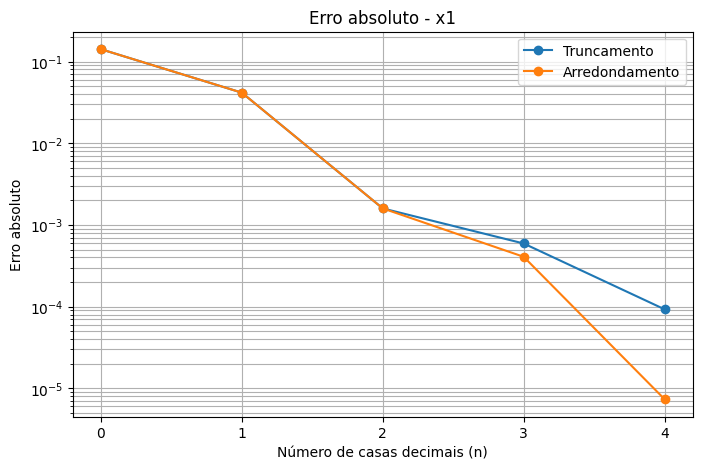

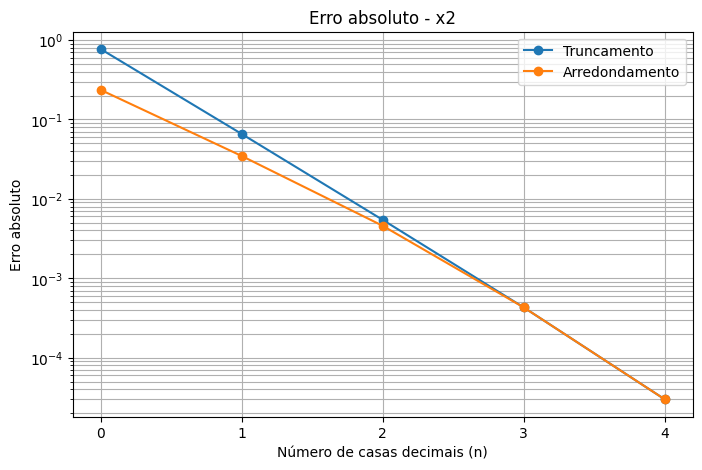

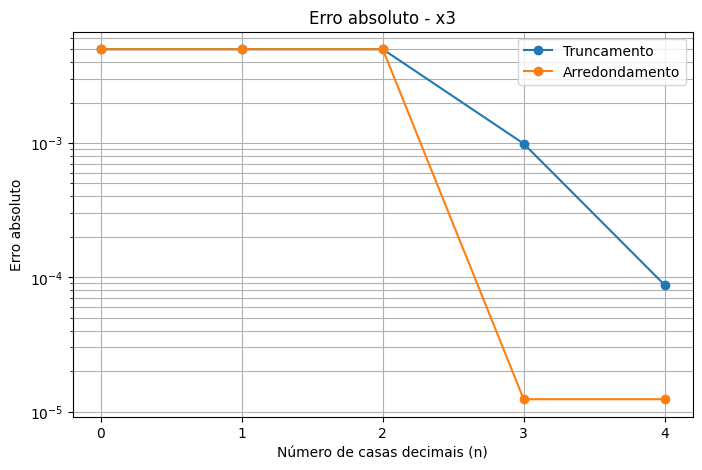

x1, n=0: Truncamento = 0.14159265, Arredondamento = 0.14159265 -> Truncamento possui erro menor
x1, n=1: Truncamento = 0.04159265, Arredondamento = 0.04159265 -> Truncamento possui erro menor
x1, n=2: Truncamento = 0.00159265, Arredondamento = 0.00159265 -> Truncamento possui erro menor
x1, n=3: Truncamento = 0.00059265, Arredondamento = 0.00040735 -> Arredondamento possui erro menor
x1, n=4: Truncamento = 9.265e-05, Arredondamento = 7.35e-06 -> Arredondamento possui erro menor
x2, n=0: Truncamento = 0.76543, Arredondamento = 0.23457 -> Arredondamento possui erro menor
x2, n=1: Truncamento = 0.06543, Arredondamento = 0.03457 -> Arredondamento possui erro menor
x2, n=2: Truncamento = 0.00543, Arredondamento = 0.00457 -> Arredondamento possui erro menor
x2, n=3: Truncamento = 0.00043, Arredondamento = 0.00043 -> Truncamento possui erro menor
x2, n=4: Truncamento = 3e-05, Arredondamento = 3e-05 -> Truncamento possui erro menor
x3, n=0: Truncamento = 0.00498765, Arredondamento = 0.00498765

In [6]:
#truncamento e arredondamento
import math
import pandas as pd
import matplotlib.pyplot as plt

valores = {
    "x1": 3.14159265,
    "x2": 98.76543,
    "x3": 0.00498765
}
casas_decimais = [0, 1, 2, 3, 4] #casas decimais

def truncar(x, n): #função para truncar
    fator = 10 ** n
    return math.trunc(x * fator) / fator

#calcuando erros
def erro_absoluto(valor_real, aproximacao):
    return abs(valor_real - aproximacao)


def erro_relativo(valor_real, aproximacao):
    return erro_absoluto(valor_real, aproximacao) / abs(valor_real)


def erro_percentual(valor_real, aproximacao):
    return erro_relativo(valor_real, aproximacao) * 100

resultados = []

for nome, valor in valores.items():

    for n in casas_decimais:

        # Truncamento
        valor_truncado = truncar(valor, n)

        # Arredondamento
        valor_arredondado = round(valor, n)

        # Erros do truncamento
        Ea_trunc = erro_absoluto(valor, valor_truncado)
        Er_trunc = erro_relativo(valor, valor_truncado)
        Ep_trunc = erro_percentual(valor, valor_truncado)

        resultados.append({
            "Valor": nome,
            "n": n,
            "Método": "Truncamento",
            "Aproximação": valor_truncado,
            "Erro absoluto": Ea_trunc,
            "Erro relativo": Er_trunc,
            "Erro percentual": Ep_trunc
        })

        # Erros do arredondamento
        Ea_arred = erro_absoluto(valor, valor_arredondado)
        Er_arred = erro_relativo(valor, valor_arredondado)
        Ep_arred = erro_percentual(valor, valor_arredondado)

        resultados.append({
            "Valor": nome,
            "n": n,
            "Método": "Arredondamento",
            "Aproximação": valor_arredondado,
            "Erro absoluto": Ea_arred,
            "Erro relativo": Er_arred,
            "Erro percentual": Ep_arred
        })


#tabela
tabela_A = pd.DataFrame(resultados)
print(tabela_A.to_string(index=False))


for nome in valores:

    print(f"\n\n========== {nome} ==========\n")

    tabela_valor = tabela_A[tabela_A["Valor"] == nome]

    print(tabela_valor.to_string(index=False))

#gráico
for nome in valores:

    dados = tabela_A[tabela_A["Valor"] == nome]

    truncamento = dados[dados["Método"] == "Truncamento"]
    arredondamento = dados[dados["Método"] == "Arredondamento"]

    plt.figure(figsize=(8, 5))

    plt.plot(
        truncamento["n"],
        truncamento["Erro absoluto"],
        marker="o",
        label="Truncamento"
    )

    plt.plot(
        arredondamento["n"],
        arredondamento["Erro absoluto"],
        marker="o",
        label="Arredondamento"
    )

    # Escala logarítmica no eixo y
    plt.yscale("log")

    plt.xlabel("Número de casas decimais (n)")
    plt.ylabel("Erro absoluto")

    plt.title(f"Erro absoluto - {nome}")

    plt.xticks(casas_decimais)

    plt.grid(True, which="both")
    plt.legend()

    plt.show()

#comparando

for nome in valores:

    dados = tabela_A[tabela_A["Valor"] == nome]

    for n in casas_decimais:

        erro_t = dados[
            (dados["n"] == n) &
            (dados["Método"] == "Truncamento")
        ]["Erro absoluto"].iloc[0]

        erro_a = dados[
            (dados["n"] == n) &
            (dados["Método"] == "Arredondamento")
        ]["Erro absoluto"].iloc[0]

        if erro_a < erro_t:
            resultado = "Arredondamento possui erro menor"
            if erro_a == erro
        else:
            resultado = "Truncamento possui erro menor"

        print(
            f"{nome}, n={n}: "
            f"Truncamento = {erro_t:.10g}, "
            f"Arredondamento = {erro_a:.10g} -> "
            f"{resultado}"
        )


ESTATÍSTICAS DAS SÉRIES

       Série  Média  Mínimo  Máximo  Amplitude  Desvio-padrão amostral
   Originais 121.12   119.8   122.4        2.6                0.833733
Arredondados 121.10   120.0   122.0        2.0                0.875595
   Truncados 120.70   119.0   122.0        3.0                0.948683

ERROS DAS MÉDIAS

       Série  Média aproximada  Erro absoluto  Erro relativo  Erro percentual (%)
Arredondados             121.1           0.02       0.000165             0.016513


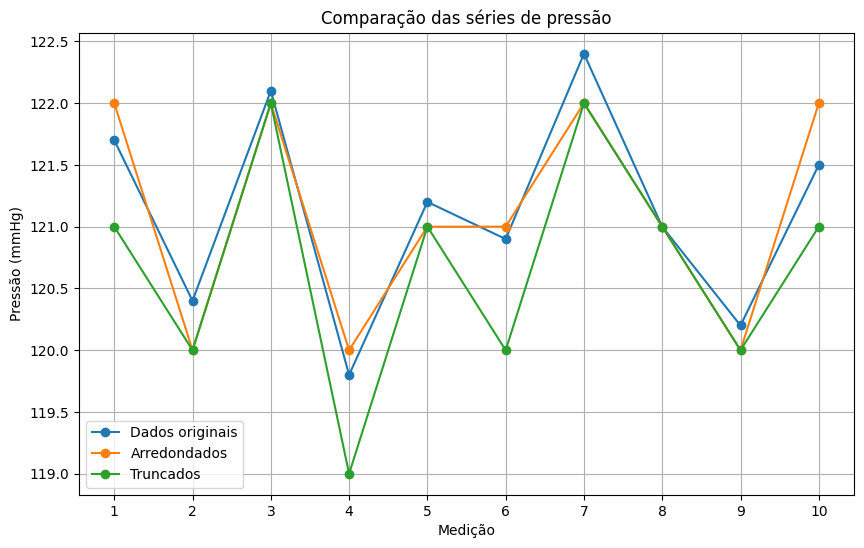

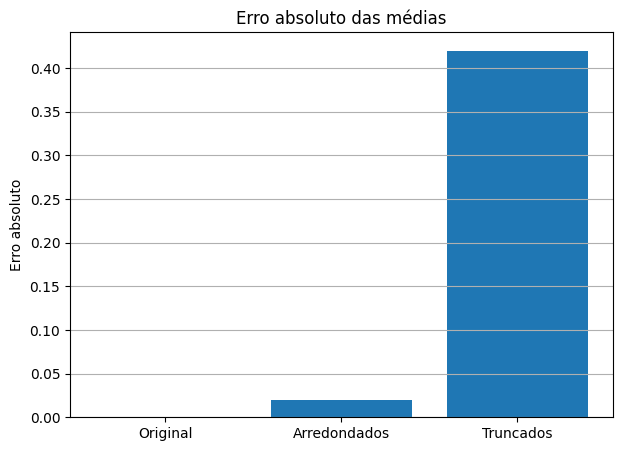

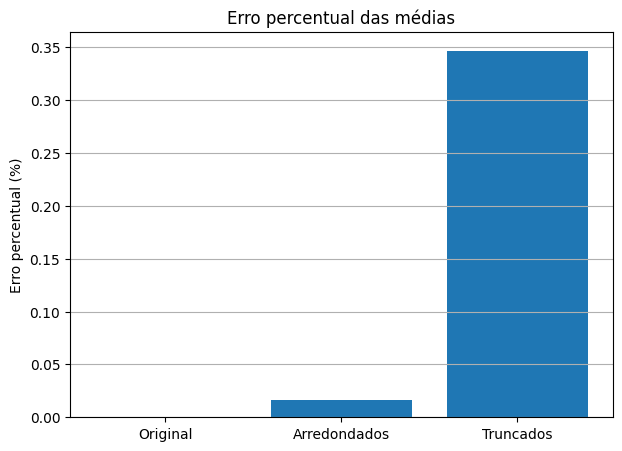

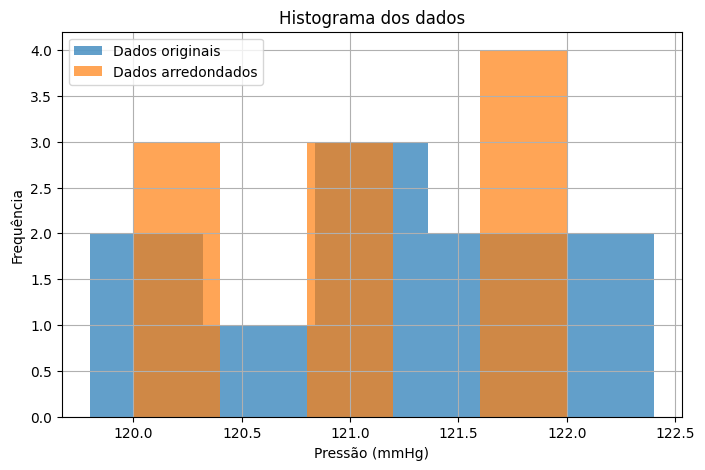

In [16]:
#medidas de pressão arterial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


dados_originais = np.array([
    121.7,
    120.4,
    122.1,
    119.8,
    121.2,
    120.9,
    122.4,
    121.0,
    120.2,
    121.5
])


#séries
# 1. Dados originais
originais = dados_originais

# 2. Dados arredondados para o inteiro mais próximo
arredondados = np.round(dados_originais)

# 3. Dados truncados para números inteiros
truncados = np.trunc(dados_originais)

#função para calcular média, mínimo, máximo, amplitude e desvio
def calcular_estatisticas(dados):

    media = np.mean(dados)
    minimo = np.min(dados)
    maximo = np.max(dados)
    amplitude = maximo - minimo
    desvio_padrao = np.std(dados, ddof=1)

    return media, minimo, maximo, amplitude, desvio_padrao
#calculando
estatisticas_originais = calcular_estatisticas(originais)

estatisticas_arredondados = calcular_estatisticas(arredondados)

estatisticas_truncados = calcular_estatisticas(truncados)

#tabela das estastísticas
tabela_estatisticas = pd.DataFrame({

    "Série": [
        "Originais",
        "Arredondados",
        "Truncados"
    ],

    "Média": [
        estatisticas_originais[0],
        estatisticas_arredondados[0],
        estatisticas_truncados[0]
    ],

    "Mínimo": [
        estatisticas_originais[1],
        estatisticas_arredondados[1],
        estatisticas_truncados[1]
    ],

    "Máximo": [
        estatisticas_originais[2],
        estatisticas_arredondados[2],
        estatisticas_truncados[2]
    ],

    "Amplitude": [
        estatisticas_originais[3],
        estatisticas_arredondados[3],
        estatisticas_truncados[3]
    ],

    "Desvio-padrão amostral": [
        estatisticas_originais[4],
        estatisticas_arredondados[4],
        estatisticas_truncados[4]
    ]
})


print("\n======================================")
print("ESTATÍSTICAS DAS SÉRIES")
print("======================================\n")

print(tabela_estatisticas.to_string(index=False))

#erros das médias
media_referencia = np.mean(dados_originais)
def calcular_erros (media_referencia, media):

    erro_absoluto = abs(media_referencia - media)

    erro_relativo = (
        erro_absoluto / abs(media_referencia)
    )

    erro_percentual = erro_relativo * 100

    return erro_absoluto, erro_relativo, erro_percentual

# Erros
erros_dados = calcular_erros(
    media_referencia,
    estatisticas_originais[0]
)

erros_arredondada = calcular_erros(
    media_referencia,
    estatisticas_arredondados[0]
)

erros_truncados = calcular_erros(
    media_referencia,
    estatisticas_truncados[0]
)
media_arredondada = round(np.mean(arredondados), 1)
erros_media_arredondada = calcular_erros(
    media_referencia,
    media_arredondada
)
#tabela dos erros da media aproximada com a de referencia
tabela_erros = pd.DataFrame({

    "Série": [
        "Arredondados",
    ],

    "Média aproximada": [
        media_arredondada,
    ],

    "Erro absoluto": [
        erros_media_arredondada[0],
    ],

    "Erro relativo": [
        erros_media_arredondada[1],
    ],

    "Erro percentual (%)": [
        erros_media_arredondada[2],
    ]
})
print("\n======================================")
print("ERROS DAS MÉDIAS")
print("======================================\n")

print(tabela_erros.to_string(index=False))

#gráfico das medições
indices = np.arange(1, 11)

plt.figure(figsize=(10, 6))

plt.plot(
    indices,
    originais,
    marker="o",
    label="Dados originais"
)

plt.plot(
    indices,
    arredondados,
    marker="o",
    label="Arredondados"
)

plt.plot(
    indices,
    truncados,
    marker="o",
    label="Truncados"
)


plt.xlabel("Medição")
plt.ylabel("Pressão (mmHg)")

plt.title("Comparação das séries de pressão")

plt.xticks(indices)

plt.grid(True)
plt.legend()

plt.show()

#gráfico dos erros absolutos
nomes = ["Original","Arredondados", "Truncados"]

erros_absolutos = [
    erros_dados[0],
    erros_arredondada[0],
    erros_truncados[0]]

plt.figure(figsize=(7, 5))

plt.bar(
    nomes,
    erros_absolutos
)

plt.ylabel("Erro absoluto")

plt.title("Erro absoluto das médias")

plt.grid(axis="y")

plt.show()

#gráfico erros percentuais
erros_percentuais = [
    erros_dados[2],
    erros_arredondada[2],
    erros_truncados[2],
]

plt.figure(figsize=(7, 5))

plt.bar(
    nomes,
    erros_percentuais
)

plt.ylabel("Erro percentual (%)")

plt.title("Erro percentual das médias")

plt.grid(axis="y")

plt.show()

#histogramas
plt.figure(figsize=(8, 5))

plt.hist(
    originais,
    bins=5,
    alpha=0.7,
    label="Dados originais"
)

plt.hist(
    arredondados,
    bins=5,
    alpha=0.7,
    label="Dados arredondados"
)

plt.xlabel("Pressão (mmHg)")
plt.ylabel("Frequência")

plt.title("Histograma dos dados")

plt.legend()
plt.grid(True)

plt.show()

In [17]:
#vazão em um tubo de pequeno diâmetro
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

#Dados
r_mm = 0.80          # mm
L = 0.20             # m
mu = 3.5e-3          # Pa.s
delta_p = 1200       # Pa

# Conversão para metros
r = r_mm / 1000

#calculando Q
def vazao(r, delta_p, mu, L):
    return (np.pi * r**4 * delta_p) / (8 * mu * L)

def erro_absoluto(real, aprox):
    return abs(real - aprox)

def erro_relativo(real, aprox):
    return abs(real - aprox) / abs(real)

def erro_percentual(real, aprox):
    return erro_relativo(real, aprox) * 100

def truncar(x, n):
    fator = 10**n
    return math.trunc(x * fator) / fator

Q_ref = vazao(r, delta_p, mu, L)

print("Q referência =", Q_ref, "m³/s")

resultados = []

#precisão do raio
r_arred_mm = round(r_mm, 1)
r_trunc_mm = truncar(r_mm, 1)

r_arred = r_arred_mm / 1000
r_trunc = r_trunc_mm / 1000

Q_r_arred = vazao(r_arred, delta_p, mu, L)
Q_r_trunc = vazao(r_trunc, delta_p, mu, L)

#precisão da viscosidade
mu_arred = round(mu, 3)
mu_trunc = truncar(mu, 3)

Q_mu_arred = vazao(r, delta_p, mu_arred, L)
Q_mu_trunc = vazao(r, delta_p, mu_trunc, L)

#precisão da pressão
dp_arred = round(delta_p, -2)
dp_trunc = truncar(delta_p, -2)

Q_dp_arred = vazao(r, dp_arred, mu, L)
Q_dp_trunc = vazao(r, dp_trunc, mu, L)

#todas aproximações
Q_total_arred = vazao(
    r_arred,
    dp_arred,
    mu_arred,
    L
)

Q_total_trunc = vazao(
    r_trunc,
    dp_trunc,
    mu_trunc,
    L
)

#tabela
cenarios = {

    "Raio arredondado": Q_r_arred,
    "Raio truncado": Q_r_trunc,
    "Viscosidade arredondada": Q_mu_arred,
    "Viscosidade truncada": Q_mu_trunc,
    "Pressão arredondada": Q_dp_arred,
    "Pressão truncada": Q_dp_trunc,
    "Tudo arredondado": Q_total_arred,
    "Tudo truncado": Q_total_trunc
}

for nome, Q in cenarios.items():

    Ea = erro_absoluto(Q_ref, Q)
    Er = erro_relativo(Q_ref, Q)
    Ep = erro_percentual(Q_ref, Q)

    resultados.append([
        nome,
        Q,
        Ea,
        Er,
        Ep
    ])

tabela = pd.DataFrame(
    resultados,
    columns=[
        "Cenário",
        "Q (m³/s)",
        "Erro absoluto",
        "Erro relativo",
        "Erro percentual"
    ]
)

print(tabela)

Q referência = 2.757420751950813e-07 m³/s
                   Cenário      Q (m³/s)  Erro absoluto  Erro relativo  \
0         Raio arredondado  2.757421e-07   0.000000e+00       0.000000   
1            Raio truncado  2.757421e-07   0.000000e+00       0.000000   
2  Viscosidade arredondada  2.412743e-07   3.446776e-08       0.125000   
3     Viscosidade truncada  3.216991e-07   4.595701e-08       0.166667   
4      Pressão arredondada  2.757421e-07   0.000000e+00       0.000000   
5         Pressão truncada  2.757421e-07   0.000000e+00       0.000000   
6         Tudo arredondado  2.412743e-07   3.446776e-08       0.125000   
7            Tudo truncado  3.216991e-07   4.595701e-08       0.166667   

   Erro percentual  
0         0.000000  
1         0.000000  
2        12.500000  
3        16.666667  
4         0.000000  
5         0.000000  
6        12.500000  
7        16.666667  
